# Introduction


This is a solution for Titanic competition using PyTorch.

# Analysis preparation

## Imports

In [1]:
from __future__ import annotations

import copy
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset


## Configuration

In [2]:
@dataclass
class Config:
    # Replace with your data paths
    train_csv: str = "/kaggle/input/competitions/titanic/train.csv"
    test_csv: str = "/kaggle/input/competitions/titanic/test.csv"
    output_model_path: str = "best_titanic_model.pt"
    output_plot_path: str = "titanic_training_curves.png"
    output_submission_path: str = "titanic_submission.csv"

    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    batch_size: int = 64
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 100
    patience: int = 15

    hidden_dims: Tuple[int, int] = (128, 64)
    dropout: float = 0.25

    val_size: float = 0.2


CFG = Config()

Set seed for experiment repeatability.

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CFG.seed)

# Feature engineering

In [4]:
def extract_title(name: str) -> str:
    if pd.isna(name):
        return "Unknown"
    if "," in name and "." in name:
        return name.split(",")[1].split(".")[0].strip()
    return "Unknown"


def simplify_title(title: str) -> str:
    rare_titles = {
        "Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major",
        "Rev", "Sir", "Jonkheer", "Dona"
    }
    if title in rare_titles:
        return "Rare"
    if title in {"Mlle", "Ms"}:
        return "Miss"
    if title == "Mme":
        return "Mrs"
    return title


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Basic missing handling helpers before feature engineering
    df["Cabin"] = df["Cabin"].fillna("Unknown")
    df["Embarked"] = df["Embarked"].fillna("Missing")
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())

    # Titles from names
    df["Title"] = df["Name"].apply(extract_title).apply(simplify_title)

    # Family-based features
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    def family_size_group(x: int) -> str:
        if x == 1:
            return "Solo"
        if 2 <= x <= 4:
            return "Small"
        return "Large"

    df["FamilySizeGroup"] = df["FamilySize"].apply(family_size_group)

    # Cabin features
    df["CabinKnown"] = (df["Cabin"] != "Unknown").astype(int)
    df["CabinDeck"] = df["Cabin"].str[0].replace("U", "Unknown")

    # Ticket group size
    ticket_counts = df["Ticket"].value_counts()
    df["TicketGroupSize"] = df["Ticket"].map(ticket_counts).fillna(1)

    # Fare-related features
    df["FarePerPerson"] = df["Fare"] / df["FamilySize"]
    df["FareBin"] = pd.qcut(
        df["Fare"],
        q=4,
        duplicates="drop",
        labels=["Fare_Q1", "Fare_Q2", "Fare_Q3", "Fare_Q4"]
    )

    # Age imputation using grouped medians
    age_group_median = df.groupby(["Sex", "Pclass", "Title"])["Age"].transform("median")
    df["Age"] = df["Age"].fillna(age_group_median)
    df["Age"] = df["Age"].fillna(df["Age"].median())

    # Age bins
    df["AgeBin"] = pd.cut(
        df["Age"],
        bins=[0, 16, 32, 48, 64, 100],
        labels=["Child", "YoungAdult", "Adult", "Mature", "Senior"],
        include_lowest=True
    )

    # Embarked cleanup
    df["Embarked"] = df["Embarked"].replace("Missing", df["Embarked"].mode()[0])

    # Log fare is often helpful
    df["LogFare"] = np.log1p(df["Fare"])

    return df


def build_feature_matrix(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.Series, StandardScaler, List[str]]:
    train_df = train_df.copy()
    test_df = test_df.copy()

    y = train_df["Survived"].values.astype(np.float32)
    test_passenger_ids = test_df["PassengerId"]

    # Keep track of train/test split through concatenation
    train_df["is_train"] = 1
    test_df["is_train"] = 0
    test_df["Survived"] = -1

    combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    combined = add_features(combined)

    # Columns to use
    numeric_cols = [
        "Pclass",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "FamilySize",
        "IsAlone",
        "CabinKnown",
        "TicketGroupSize",
        "FarePerPerson",
        "LogFare",
    ]

    categorical_cols = [
        "Sex",
        "Embarked",
        "Title",
        "FamilySizeGroup",
        "CabinDeck",
        "FareBin",
        "AgeBin",
    ]

    # One-hot encode categoricals
    combined_encoded = pd.get_dummies(
        combined[numeric_cols + categorical_cols],
        columns=categorical_cols,
        drop_first=False,
        dummy_na=False
    )

    feature_names = combined_encoded.columns.tolist()

    # Split back
    X_all = combined_encoded.values.astype(np.float32)
    is_train_mask = combined["is_train"].values == 1

    X_train_full = X_all[is_train_mask]
    X_test = X_all[~is_train_mask]

    # Scale only numeric-like continuous columns across all encoded features
    # Better: scale original continuous columns by index
    scaler = StandardScaler()
    numeric_indices = [feature_names.index(col) for col in numeric_cols]
    X_train_full_scaled = X_train_full.copy()
    X_test_scaled = X_test.copy()

    X_train_full_scaled[:, numeric_indices] = scaler.fit_transform(X_train_full[:, numeric_indices])
    X_test_scaled[:, numeric_indices] = scaler.transform(X_test[:, numeric_indices])

    return X_train_full_scaled, y, X_test_scaled, test_passenger_ids, scaler, feature_names


# Build dataset

In [5]:
class TitanicDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray | None = None) -> None:
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]


# Training

In [6]:
class TitanicMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: Tuple[int, int], dropout: float) -> None:
        super().__init__()

        h1, h2 = hidden_dims

        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(h2, 1)
        )

        self._init_weights()

    def _init_weights(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Metrics and validation

In [7]:
def binary_accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    correct = (preds == targets).float().mean()
    return float(correct.item())


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: str
) -> Tuple[float, float]:
    model.train()

    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += binary_accuracy_from_logits(logits, yb)
        n_batches += 1

    return running_loss / n_batches, running_acc / n_batches


@torch.no_grad()
def validate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: str
) -> Tuple[float, float]:
    model.eval()

    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item()
        running_acc += binary_accuracy_from_logits(logits, yb)
        n_batches += 1

    return running_loss / n_batches, running_acc / n_batches


def plot_training_curves(history: Dict[str, List[float]], output_path: str) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves")
    plt.legend()

    plt.subplot(1, 2, 2)
    train_error = [1.0 - x for x in history["train_acc"]]
    val_error = [1.0 - x for x in history["val_acc"]]

    plt.plot(epochs, train_error, label="Train Error")
    plt.plot(epochs, val_error, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.title("Error Curves")
    plt.legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()



# Data preparation and training


## Load the data

In [8]:
train_path = Path(CFG.train_csv)
test_path = Path(CFG.test_csv)

if not train_path.exists():
    raise FileNotFoundError(f"Could not find {CFG.train_csv}")
if not test_path.exists():
    raise FileNotFoundError(f"Could not find {CFG.test_csv}")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

## Perform train / valid split

In [9]:
X_train_full, y_train_full, X_test, test_passenger_ids, _, feature_names = build_feature_matrix(
    train_df=train_df,
    test_df=test_df
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=CFG.val_size,
    random_state=CFG.seed,
    stratify=y_train_full
)

## Prepare the dataset

In [10]:
train_dataset = TitanicDataset(X_train, y_train)
val_dataset = TitanicDataset(X_val, y_val)
test_dataset = TitanicDataset(X_test, None)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=0
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=0
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=0
)

## Training

In [11]:
model = TitanicMLP(
    input_dim=X_train.shape[1],
    hidden_dims=CFG.hidden_dims,
    dropout=CFG.dropout
).to(CFG.device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

history: Dict[str, List[float]] = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

print(f"Device: {CFG.device}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Input dim:     {X_train.shape[1]}")

for epoch in range(1, CFG.epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=CFG.device
    )
    val_loss, val_acc = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=CFG.device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:03d} | "
        f"lr={current_lr:.6f} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "feature_names": feature_names,
            "input_dim": X_train.shape[1],
            "config": CFG.__dict__,
            "best_val_loss": best_val_loss,
        }
        torch.save(best_state, CFG.output_model_path)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= CFG.patience:
        print(f"Early stopping triggered after {epoch} epochs.")
        break

Device: cpu
Train samples: 712
Val samples:   179
Test samples:  418
Input dim:     43
Epoch 001 | lr=0.001000 | train_loss=0.8330 | train_acc=0.5430 | val_loss=0.6262 | val_acc=0.7040
Epoch 002 | lr=0.001000 | train_loss=0.6582 | train_acc=0.6628 | val_loss=0.5530 | val_acc=0.7445
Epoch 003 | lr=0.001000 | train_loss=0.5606 | train_acc=0.7396 | val_loss=0.5035 | val_acc=0.7849
Epoch 004 | lr=0.001000 | train_loss=0.4958 | train_acc=0.7799 | val_loss=0.4786 | val_acc=0.7901
Epoch 005 | lr=0.001000 | train_loss=0.4932 | train_acc=0.7799 | val_loss=0.4617 | val_acc=0.8162
Epoch 006 | lr=0.001000 | train_loss=0.4259 | train_acc=0.8151 | val_loss=0.4552 | val_acc=0.8279
Epoch 007 | lr=0.001000 | train_loss=0.4406 | train_acc=0.8086 | val_loss=0.4503 | val_acc=0.8214
Epoch 008 | lr=0.001000 | train_loss=0.4096 | train_acc=0.8203 | val_loss=0.4468 | val_acc=0.8110
Epoch 009 | lr=0.001000 | train_loss=0.4289 | train_acc=0.8125 | val_loss=0.4430 | val_acc=0.8123
Epoch 010 | lr=0.001000 | train

## Visualize train/validation

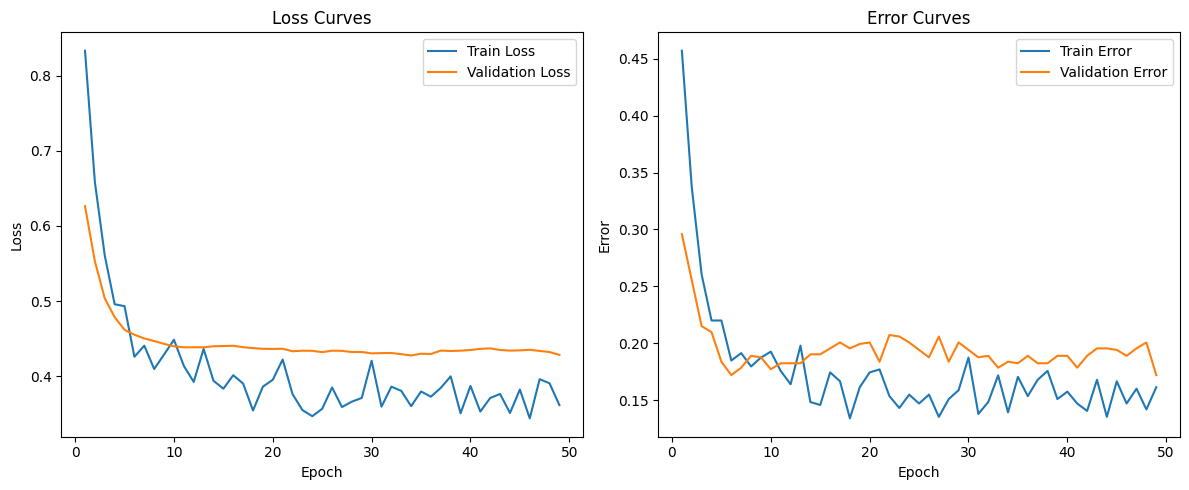

In [12]:
plot_training_curves(history, CFG.output_plot_path)

# Prepare submission

In [13]:
if best_state is None:
    raise RuntimeError("Training failed: no best model state was saved.")

model.load_state_dict(best_state["model_state_dict"])

# Final validation score with best model
final_val_loss, final_val_acc = validate_one_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=CFG.device
)
print(f"\nBest validation loss: {final_val_loss:.4f}")
print(f"Best validation accuracy: {final_val_acc:.4f}")

# Predict on Kaggle test set
model.eval()
test_probs = []

with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(CFG.device)
        logits = model(xb)
        probs = torch.sigmoid(logits).squeeze(1)
        test_probs.extend(probs.cpu().numpy().tolist())

test_preds = [1 if p >= 0.5 else 0 for p in test_probs]

submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": test_preds
})
submission.to_csv(CFG.output_submission_path, index=False)

print(f"Saved model to:      {CFG.output_model_path}")
print(f"Saved curves to:     {CFG.output_plot_path}")
print(f"Saved submission to: {CFG.output_submission_path}")


Best validation loss: 0.4276
Best validation accuracy: 0.8162
Saved model to:      best_titanic_model.pt
Saved curves to:     titanic_training_curves.png
Saved submission to: titanic_submission.csv
